# Introduction
There has been recent discourse over the increased use of generative AI amongst students. Due to this rising trend I think it's important to understand its possible implications as it pertains to scholastic performance, and its use. To help me gain some insight into this increase in popularity of generative AI I'll be analyzing a dataset collected from students at the collegiate level.  
## Goal
My goal for this project is to identify driving factors for the adoption of generative AI amongst students and its effect on academic performance.
### Questions
1. What is the most common use for generative AI?
2. Is there a relationship between academic performance and generative AI use?
3. Is there a stronger correlation between academic performance and generative AI use than academic performance and traditional studying?

In [27]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
#load data
data = pd.read_csv('ai_student_impact_dataset_original.csv')

data.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


In [29]:
#data information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  str    
 2   Year_of_Study               50000 non-null  str    
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  str    
 6   Prompt_Engineering_Skill    50000 non-null  str    
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  str    
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           50000 non-null

In [30]:
#data description except for the Student_ID column
data.drop(columns=['Student_ID']).describe(include = 'all')

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
count,50000,50000,50000.000000,50000.000000,50000,50000,50000.00000,50000,50000.000000,50000.000000,50000,50000.000000,50000.000000,50000.000000,50000
unique,5,5,NaN,NaN,5,3,NaN,2,NaN,NaN,3,NaN,NaN,NaN,3
top,STEM,Junior,NaN,NaN,Debugging/Troubleshooting,Beginner,NaN,False,NaN,NaN,Allowed_With_Citation,NaN,NaN,NaN,Medium
freq,15059,11045,NaN,NaN,12295,18495,NaN,28846,NaN,NaN,25224,NaN,NaN,NaN,21144
mean,NaN,NaN,3.146102,8.427752,NaN,NaN,2.80026,NaN,11.209271,3.505360,NaN,4.270760,3.349299,75.798125,NaN
std,NaN,NaN,0.478854,8.269490,NaN,NaN,1.18802,NaN,5.156426,1.820812,NaN,2.144066,0.495673,13.281626,NaN
min,NaN,NaN,1.183000,0.000000,NaN,NaN,1.00000,NaN,1.000000,1.000000,NaN,1.000000,1.000000,10.780000,NaN
25%,NaN,NaN,2.834000,2.390000,NaN,NaN,2.00000,NaN,7.560000,2.000000,NaN,3.000000,3.023750,66.820000,NaN
50%,NaN,NaN,3.210000,5.800000,NaN,NaN,3.00000,NaN,11.180000,3.000000,NaN,4.000000,3.421000,76.000000,NaN
75%,NaN,NaN,3.521000,11.720000,NaN,NaN,4.00000,NaN,14.710000,5.000000,NaN,6.000000,3.749000,85.190000,NaN


In [31]:
#view columns
dataset_columns = data.columns

print(dataset_columns)

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level'],
      dtype='str')


In [32]:
#check for exact duplicates
exact_dups = data.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_dups}")

#check for parital duplicates based on Student ID 
partial_dups = data.duplicated(subset = ['Student_ID']).sum()
print(f"Number of partial duplicate rows based on Student ID: {partial_dups}")


Number of exact duplicate rows: 0
Number of partial duplicate rows based on Student ID: 0


In [33]:
#round the GPA columns to two decimal places
data[['Pre_Semester_GPA', 'Post_Semester_GPA']] = round(data[['Pre_Semester_GPA', 'Post_Semester_GPA']], 2)

data[['Pre_Semester_GPA', 'Post_Semester_GPA']].head()

,Pre_Semester_GPA,Post_Semester_GPA
0,2.42,2.39
1,3.82,3.70
2,3.40,3.50
3,3.79,4.00
4,3.64,3.80


In [34]:
#check the unique values in each column excluding 'Student_ID' and continuous variables
for column in dataset_columns.drop('Student_ID'):
    data_col = data[column]
    if data_col.dtypes != 'float':
        if data_col.dtypes == 'str':
            print(f'Unique values in {column}: {list(data_col.unique())}', '\n')
        else:
            print(f'Unique values in {column}: {data_col.unique()}', '\n')

Unique values in Major_Category: ['Humanities', 'Medical', 'Business', 'STEM', 'Arts'] 

Unique values in Year_of_Study: ['Senior', 'Junior', 'Freshman', 'Sophomore', 'Graduate'] 

Unique values in Primary_Use_Case: ['Copywriting/Drafting', 'Ideation', 'Summarizing_Reading', 'Debugging/Troubleshooting', 'Direct_Answer_Generation'] 

Unique values in Prompt_Engineering_Skill: ['Beginner', 'Advanced', 'Intermediate'] 

Unique values in Tool_Diversity: [1 5 2 4 3] 

Unique values in Paid_Subscription: [ True False] 

Unique values in Perceived_AI_Dependency: [ 5  3  2  4  8  1  6  7 10  9] 

Unique values in Institutional_Policy: ['Allowed_With_Citation', 'Strict_Ban', 'Actively_Encouraged'] 

Unique values in Anxiety_Level_During_Exams: [ 6  9  2  4  5  7  1  8  3 10] 

Unique values in Burnout_Risk_Level: ['High', 'Low', 'Medium'] 



In [35]:
#replace 'Medium' with 'Moderate' in the Burnout_Risk_Level column
data['Burnout_Risk_Level'] = data['Burnout_Risk_Level'].replace({'Medium': 'Moderate'})

data['Burnout_Risk_Level'].head()

0        High
1         Low
2    Moderate
3    Moderate
4    Moderate
Name: Burnout_Risk_Level, dtype: str

In [36]:
data['Primary_Use_Case'] = data['Primary_Use_Case'].replace({'Copywriting/Drafting' : 'Drafting', 'Summarizing_Reading' : 'Summarizing', 
                                                             'Debugging/Troubleshooting' : 'Troubleshooting', 'Direct_Answer_Generation' : 'Answer_Generation'})

print(f'Primary_Use_Case reformatted values: {list(data["Primary_Use_Case"].unique())}')

Primary_Use_Case reformatted values: ['Drafting', 'Ideation', 'Summarizing', 'Troubleshooting', 'Answer_Generation']


In [37]:
#create a function for converting GPAs to letter grades

def assign_letter_grade(gpa):
    if gpa >= 3.7:
        return 'A'
    elif gpa >= 2.7:
        return 'B'
    elif gpa >= 1.7:
        return 'C'
    elif gpa >= 0.7:
        return 'D'
    else:
        return 'F'
    
#create new column with letter grades
data['Pre_Sem_Letter_Grade'] = data['Pre_Semester_GPA'].apply(assign_letter_grade)

data['Post_Sem_Letter_Grade'] = data['Post_Semester_GPA'].apply(assign_letter_grade)

data[['Pre_Semester_GPA', 'Pre_Sem_Letter_Grade', 'Post_Semester_GPA','Post_Sem_Letter_Grade']].head(10)

,Pre_Semester_GPA,Pre_Sem_Letter_Grade,Post_Semester_GPA,Post_Sem_Letter_Grade
0,2.42,C,2.39,C
1,3.82,A,3.70,A
2,3.40,B,3.50,B
3,3.79,A,4.00,A
4,3.64,B,3.80,A
5,3.45,B,3.67,B
6,3.62,B,4.00,A
7,2.75,B,2.96,B
8,3.42,B,3.40,B
9,3.05,B,2.98,B


In [38]:
#create a bracket for time spent using AI tools or traditional study methods
def assign_time_bracket(time_spent):
    if time_spent >= 25:
        return 'High'
    elif time_spent >= 15:
        return 'Moderate'
    else:
        return 'Low'

data['AI_Usage_Cat'] = data['Weekly_GenAI_Hours'].apply(assign_time_bracket)

data['Study_Time_Cat'] = data['Traditional_Study_Hours'].apply(assign_time_bracket)

data[['Weekly_GenAI_Hours','AI_Usage_Cat', 'Traditional_Study_Hours', 'Study_Time_Cat']].head(10)

,Weekly_GenAI_Hours,AI_Usage_Cat,Traditional_Study_Hours,Study_Time_Cat
0,23.31,Moderate,8.13,Low
1,1.12,Low,16.65,Moderate
2,21.26,Moderate,10.35,Low
3,1.82,Low,15.23,Moderate
4,9.29,Low,12.55,Low
5,6.50,Low,14.19,Low
6,31.41,High,13.11,Low
7,5.33,Low,18.45,Moderate
8,2.00,Low,2.87,Low
9,19.99,Moderate,12.49,Low


In [39]:
#calculate the change in GPA
data['GPA_Change'] = data['Post_Semester_GPA'] - data['Pre_Semester_GPA']

data[[ 'Pre_Semester_GPA','GPA_Change', 'Post_Semester_GPA']].head()

,Pre_Semester_GPA,GPA_Change,Post_Semester_GPA
0,2.42,-0.03,2.39
1,3.82,-0.12,3.70
2,3.40,0.10,3.50
3,3.79,0.21,4.00
4,3.64,0.16,3.80


In [40]:
#view the columns after creating the new columns
data.columns

Index(['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Weekly_GenAI_Hours', 'Primary_Use_Case', 'Prompt_Engineering_Skill',
       'Tool_Diversity', 'Paid_Subscription', 'Traditional_Study_Hours',
       'Perceived_AI_Dependency', 'Institutional_Policy',
       'Anxiety_Level_During_Exams', 'Post_Semester_GPA',
       'Skill_Retention_Score', 'Burnout_Risk_Level', 'Pre_Sem_Letter_Grade',
       'Post_Sem_Letter_Grade', 'AI_Usage_Cat', 'Study_Time_Cat',
       'GPA_Change'],
      dtype='str')

In [42]:
#reorder columns
data = data[['Student_ID', 'Major_Category', 'Year_of_Study', 'Pre_Semester_GPA',
       'Pre_Sem_Letter_Grade', 'Post_Semester_GPA', 'Post_Sem_Letter_Grade', 'GPA_Change',
       'Primary_Use_Case', 'Weekly_GenAI_Hours', 'AI_Usage_Cat', 'Traditional_Study_Hours',
       'Study_Time_Cat','Prompt_Engineering_Skill', 'Tool_Diversity', 'Paid_Subscription',
       'Perceived_AI_Dependency', 'Institutional_Policy', 'Anxiety_Level_During_Exams',
       'Skill_Retention_Score', 'Burnout_Risk_Level']]

data.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Pre_Sem_Letter_Grade,Post_Semester_GPA,Post_Sem_Letter_Grade,GPA_Change,Primary_Use_Case,Weekly_GenAI_Hours,...,Traditional_Study_Hours,Study_Time_Cat,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.42,C,2.39,C,-0.03,Drafting,23.31,...,8.13,Low,Beginner,1,True,5,Allowed_With_Citation,6,86.44,High
1,100002,Medical,Junior,3.82,A,3.70,A,-0.12,Ideation,1.12,...,16.65,Moderate,Advanced,5,False,3,Allowed_With_Citation,9,69.39,Low
2,100003,Business,Freshman,3.40,B,3.50,B,0.10,Summarizing,21.26,...,10.35,Low,Beginner,2,False,5,Strict_Ban,9,73.93,Moderate
3,100004,Business,Senior,3.79,A,4.00,A,0.21,Drafting,1.82,...,15.23,Moderate,Intermediate,4,False,2,Allowed_With_Citation,2,63.58,Moderate
4,100005,STEM,Sophomore,3.64,B,3.80,A,0.16,Troubleshooting,9.29,...,12.55,Low,Advanced,4,False,4,Allowed_With_Citation,4,100.00,Moderate


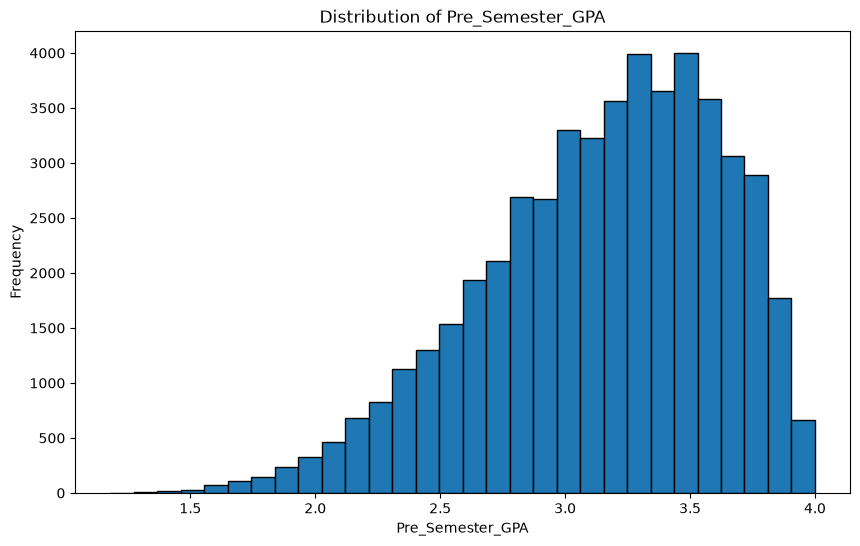

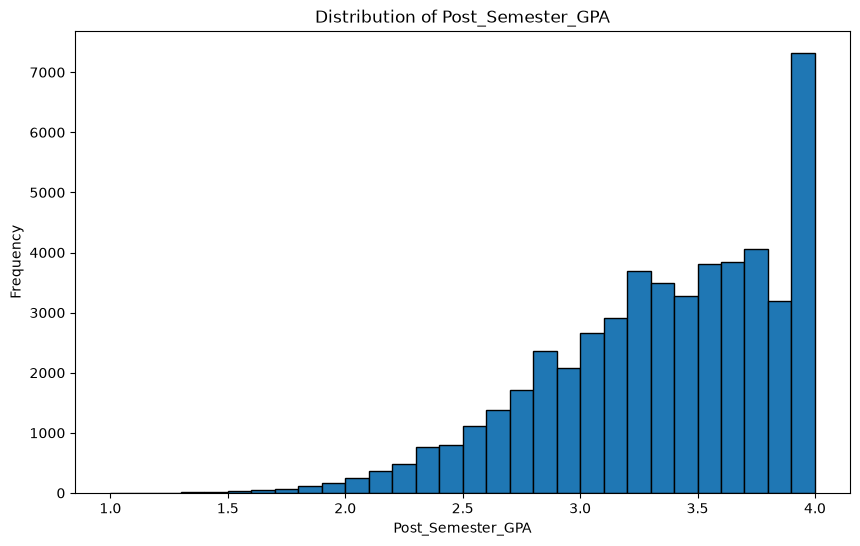

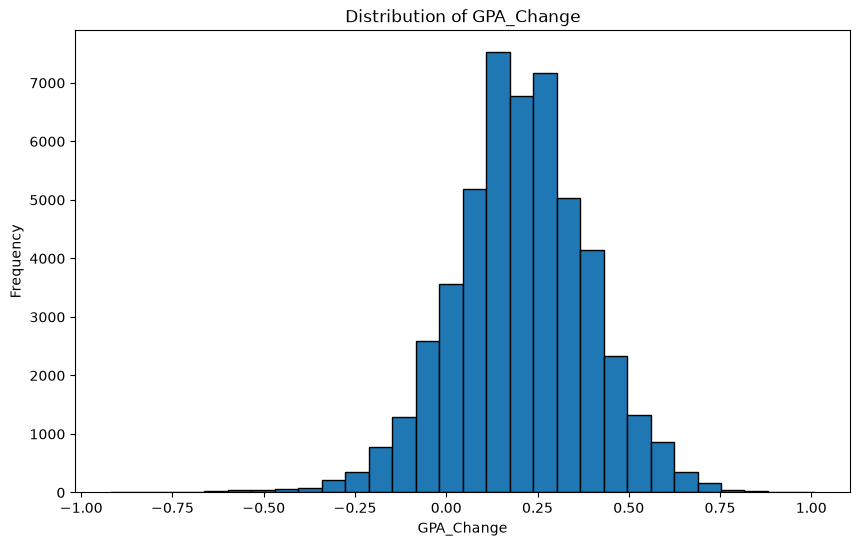

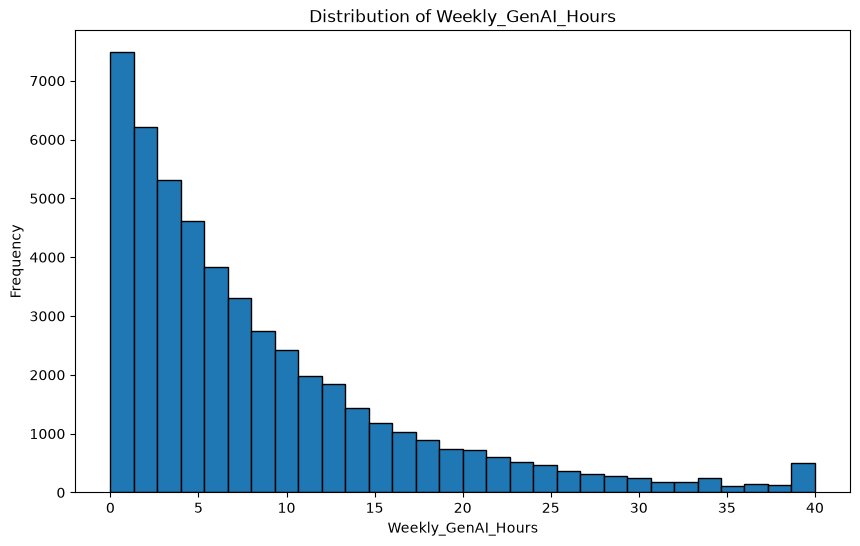

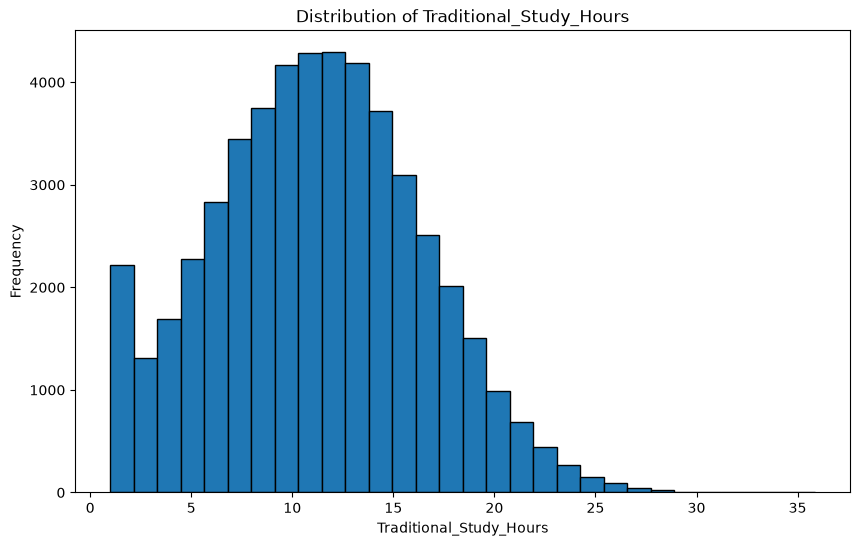

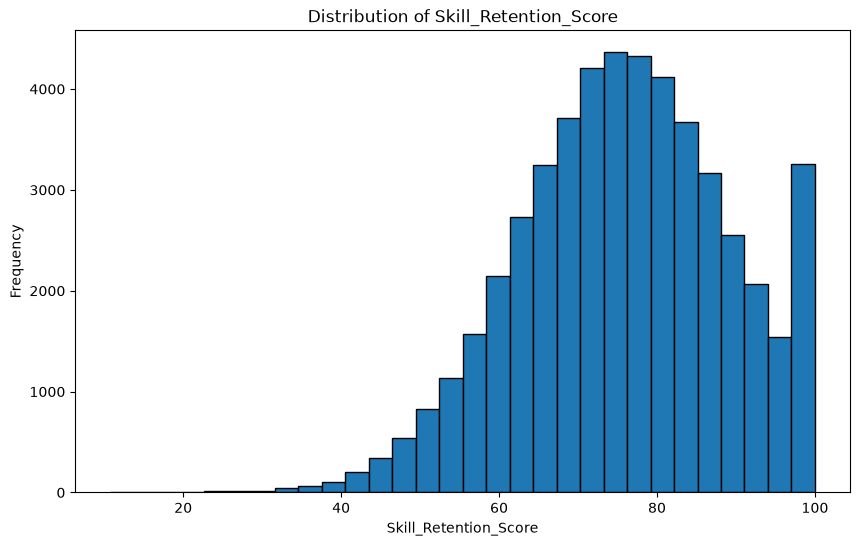

In [43]:
#plot histograms for the continuous variables

for column in data.drop(columns = ['Student_ID']).select_dtypes(include=[float]).columns:
    plt.figure(figsize=(10, 6))
    plt.hist(data[column], bins=30, edgecolor='black')
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()